In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

# القنوات الإعلانية
channels = [
    "Google Ads",
    "Facebook Ads",
    "Instagram Ads",
    "TikTok Ads",
    "Email",
    "Organic Search"
]

# تاريخ الحملة (6 شهور)
dates = pd.date_range(start="2024-01-01", end="2024-06-30")

data = []

for date in dates:
    for channel in channels:

        # impressions تختلف حسب القناة
        base_impressions = {
            "Google Ads": np.random.randint(8000,15000),
            "Facebook Ads": np.random.randint(6000,12000),
            "Instagram Ads": np.random.randint(5000,10000),
            "TikTok Ads": np.random.randint(7000,13000),
            "Email": np.random.randint(2000,5000),
            "Organic Search": np.random.randint(4000,9000)
        }

        impressions = base_impressions[channel]

        # CTR مختلف لكل قناة
        ctr = {
            "Google Ads": np.random.uniform(0.04,0.08),
            "Facebook Ads": np.random.uniform(0.03,0.06),
            "Instagram Ads": np.random.uniform(0.025,0.05),
            "TikTok Ads": np.random.uniform(0.02,0.045),
            "Email": np.random.uniform(0.05,0.12),
            "Organic Search": np.random.uniform(0.06,0.12)
        }

        clicks = int(impressions * ctr[channel])

        # تكلفة النقرة
        cpc = {
            "Google Ads": np.random.uniform(0.6,1.2),
            "Facebook Ads": np.random.uniform(0.4,0.9),
            "Instagram Ads": np.random.uniform(0.5,1),
            "TikTok Ads": np.random.uniform(0.3,0.8),
            "Email": np.random.uniform(0.05,0.2),
            "Organic Search": 0
        }

        cost = clicks * cpc[channel]

        # conversion rate
        conversion_rate = {
            "Google Ads": np.random.uniform(0.03,0.06),
            "Facebook Ads": np.random.uniform(0.02,0.05),
            "Instagram Ads": np.random.uniform(0.02,0.04),
            "TikTok Ads": np.random.uniform(0.015,0.035),
            "Email": np.random.uniform(0.05,0.1),
            "Organic Search": np.random.uniform(0.04,0.08)
        }

        purchases = int(clicks * conversion_rate[channel])

        # متوسط سعر الطلب
        aov = np.random.uniform(40,120)

        revenue = purchases * aov

        data.append([
            date,
            channel,
            impressions,
            clicks,
            round(cost,2),
            purchases,
            round(revenue,2)
        ])

df = pd.DataFrame(data, columns=[
    "date",
    "channel",
    "impressions",
    "clicks",
    "cost",
    "purchases",
    "revenue"
])

print(df.head())
print(df.shape)


        date        channel  impressions  clicks    cost  purchases  revenue
0 2024-01-01     Google Ads         8860     389  401.91         18  2122.21
1 2024-01-01   Facebook Ads         6189     295  260.43          9   546.32
2 2024-01-01  Instagram Ads         6021     267  159.66          9   461.47
3 2024-01-01     TikTok Ads         9568     361  261.73         10   848.99
4 2024-01-01          Email         3028     156   29.04          8   423.18
(1092, 7)


In [2]:
# 1 compration between channels in performance and cost
#2 performance based on monthes
#3 relationchips between features like purches and revenue , cost and clicks , rov , aov,roas, net profit

In [3]:
df.sample()

,date,channel,impressions,clicks,cost,purchases,revenue
56,2024-01-10,Instagram Ads,9444,279,217.4,8,617.34


In [4]:
## لو هدفك ذيادة الوعي بالمنتج بتاعك ف الايميل مش افضل خيار

## email and search organic : مناسبين جدا لو المصاريف قليله
## السوشيال افضل لل awarnes

## calculate ctr ,roi

In [5]:
df['ctr']=df['clicks']/df['impressions']

In [6]:
df['roi']=(df['revenue']-df['cost'])/df['cost']

In [7]:
totals=df.groupby('channel')[['impressions','clicks','cost','ctr','roi']].sum()
print(totals)

                impressions  clicks       cost        ctr          roi
channel                                                               
Email                644492   52760    6885.04  15.022945  9416.205005
Facebook Ads        1630527   74407   48292.98   8.334364   648.303663
Google Ads          2076392  124911  113727.74  10.923304   571.542069
Instagram Ads       1328479   49909   36086.20   6.826936   427.393940
Organic Search      1174389  106433       0.00  16.407891          inf
TikTok Ads          1819693   58780   31994.05   5.899089   495.596739


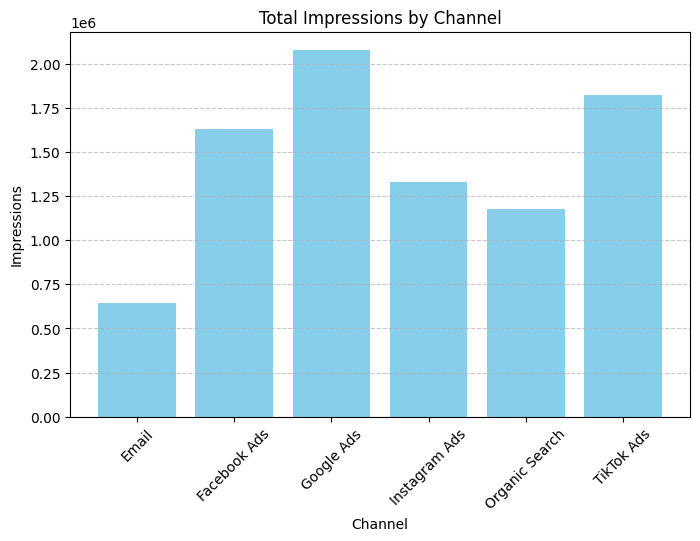

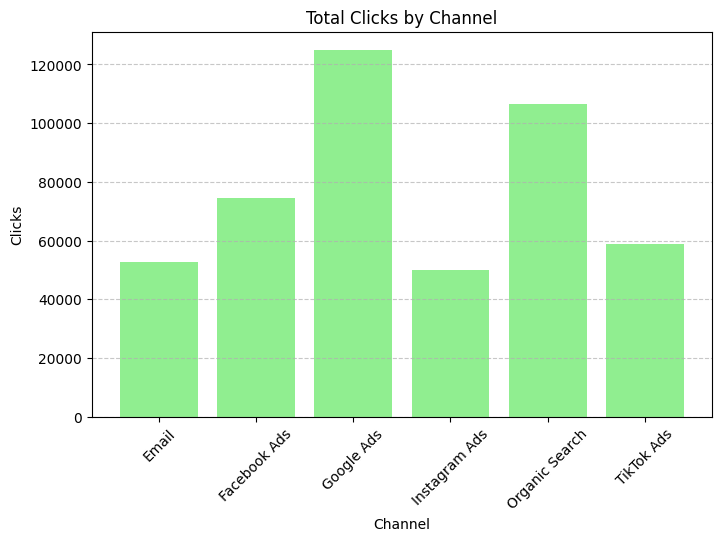

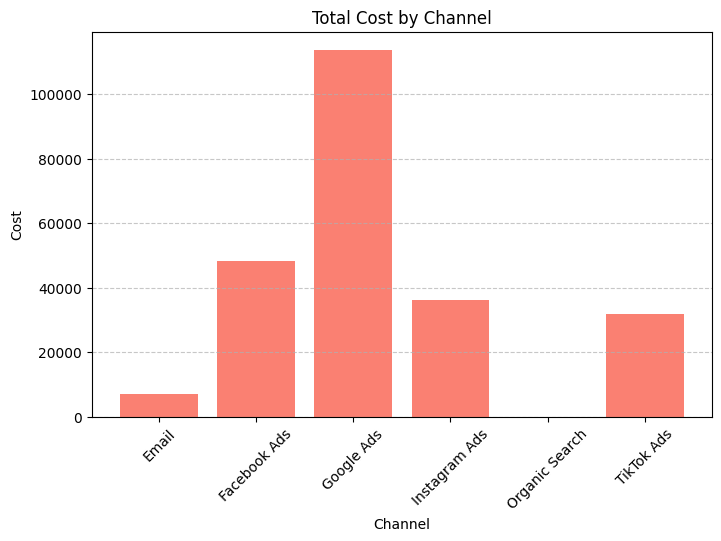

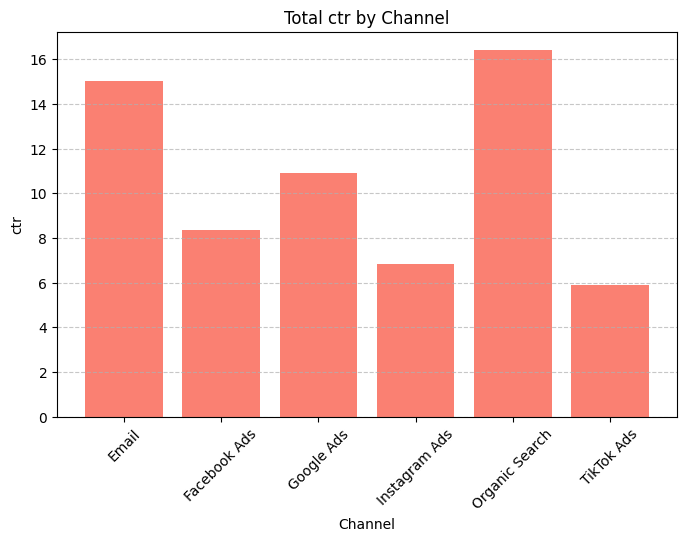

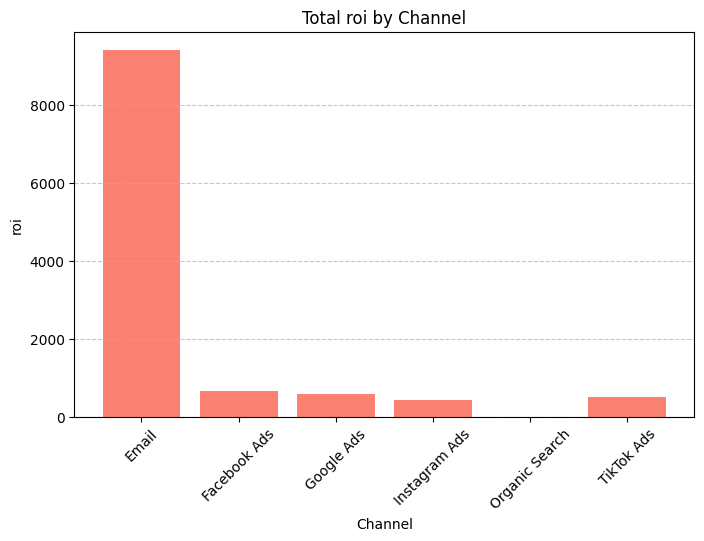

In [8]:
# 1️⃣ Impressions
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(totals.index, totals['impressions'], color='skyblue')
plt.title("Total Impressions by Channel")
plt.ylabel("Impressions")
plt.xlabel("Channel")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2️⃣ Clicks
plt.figure(figsize=(8,5))
plt.bar(totals.index, totals['clicks'], color='lightgreen')
plt.title("Total Clicks by Channel")
plt.ylabel("Clicks")
plt.xlabel("Channel")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3️⃣ Cost
plt.figure(figsize=(8,5))
plt.bar(totals.index, totals['cost'], color='salmon')
plt.title("Total Cost by Channel")
plt.ylabel("Cost")
plt.xlabel("Channel")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
#ctr
plt.figure(figsize=(8,5))
plt.bar(totals.index, totals['ctr'], color='salmon')
plt.title("Total ctr by Channel")
plt.ylabel("ctr")
plt.xlabel("Channel")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


#roi
plt.figure(figsize=(8,5))
plt.bar(totals.index, totals['roi'], color='salmon')
plt.title("Total roi by Channel")
plt.ylabel("roi")
plt.xlabel("Channel")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## insights
1 emails : فعلاه جدا من ناحية التعاملات الماليه مقابل التفاعل ف ممكن نركز عليها و دا دليل ان الناس المستهدفين من الاعلانات دي مهتمين اكتر بالمنتج
2 google ads :أعلى عدد نقرات: Google Ads (124,911) → رغم CTR 10.9%، حجم الـ  لو لو الهدف ذيادة الزيارات بشكل عام ف هو خيار مثالي impressions كبير جدًا

In [9]:
df.sample()

,date,channel,impressions,clicks,cost,purchases,revenue,ctr,roi
300,2024-02-20,Google Ads,8599,390,443.08,13,1413.09,0.045354,2.189243


## over monthes

In [10]:
df['month']=df['date'].dt.month

In [17]:
monthly_impressions = df.groupby('month')['impressions'].sum()
monthly_clciks = df.groupby('month')['clicks'].sum()
monthly_revinue = df.groupby('month')['revenue'].sum()

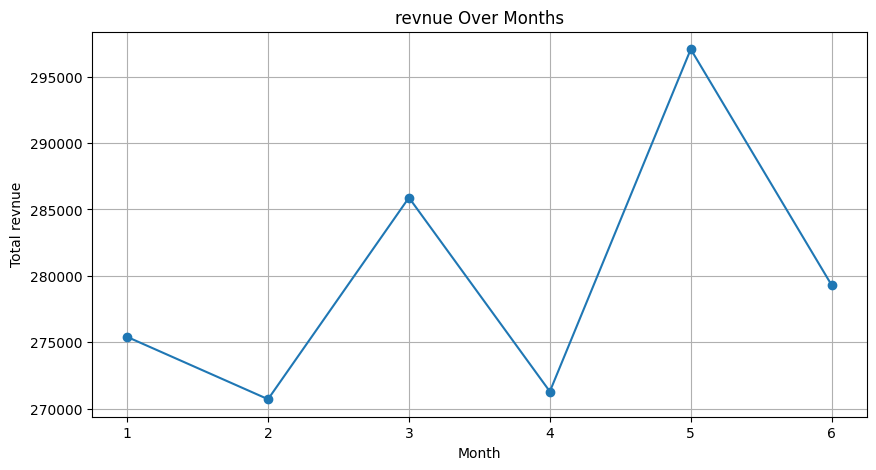

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(monthly_revinue.index, monthly_revinue.values, marker='o')

plt.title('revnue Over Months')
plt.xlabel('Month')
plt.ylabel('Total revnue')

plt.grid(True)

plt.show()

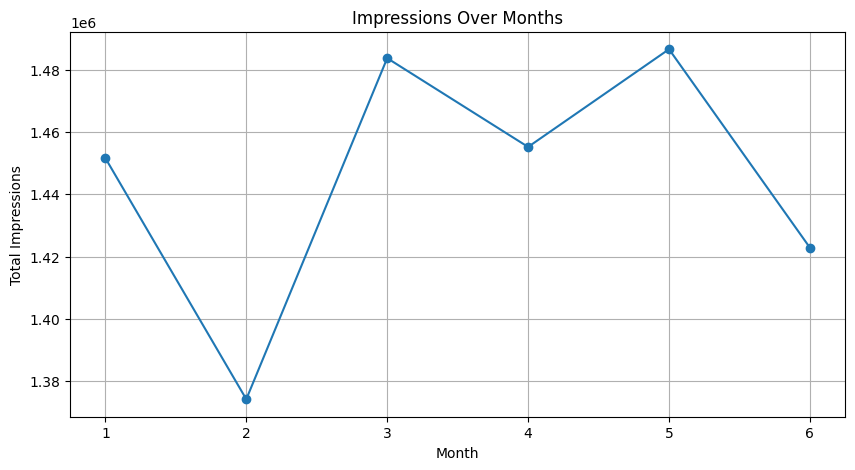

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(monthly_impressions.index, monthly_impressions.values, marker='o')

plt.title('Impressions Over Months')
plt.xlabel('Month')
plt.ylabel('Total Impressions')

plt.grid(True)

plt.show()

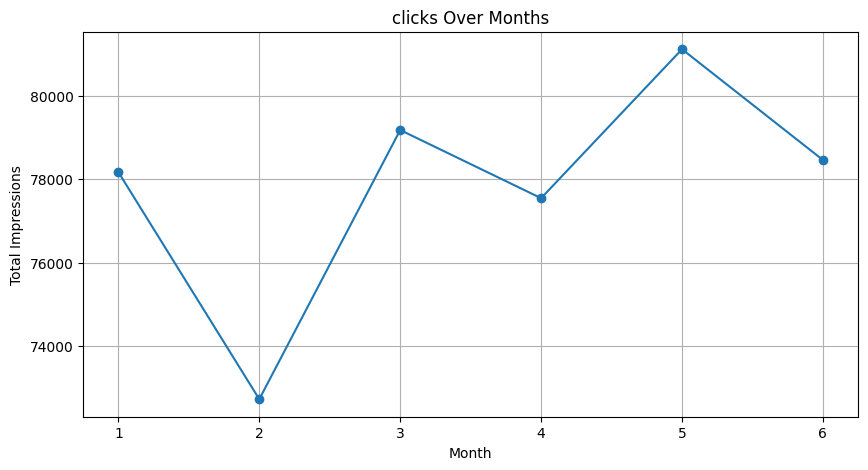

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(monthly_clciks.index, monthly_clciks.values, marker='o')

plt.title('clicks Over Months')
plt.xlabel('Month')
plt.ylabel('Total Impressions')

plt.grid(True)

plt.show()

In [20]:
df.to_csv('marketing_data.csv', index=False)

In [21]:
from google.colab import files
files.download('marketing_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>